Visualisations of the stability experiments in ClusterGraph_stability_computations.ipynb

In [1]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import colormaps as cm
from matplotlib.lines import Line2D


with open("ClusterGraph_results_stability/sensitivity_analysis_diabete.json", "r") as f:
    results_diabete = json.load(f)

with open("ClusterGraph_results_stability/sensitivity_analysis_concentric_circles.json", "r") as f:
    results_circles = json.load(f)

with open("ClusterGraph_results_stability/sensitivity_analysis_mice_protein.json", "r") as f:
    results_mice = json.load(f)
    
with open("ClusterGraph_results_stability/sensitivity_analysis_lung_cancer.json", "r") as f:
    results_lung_cancer = json.load(f)

# K nn varying

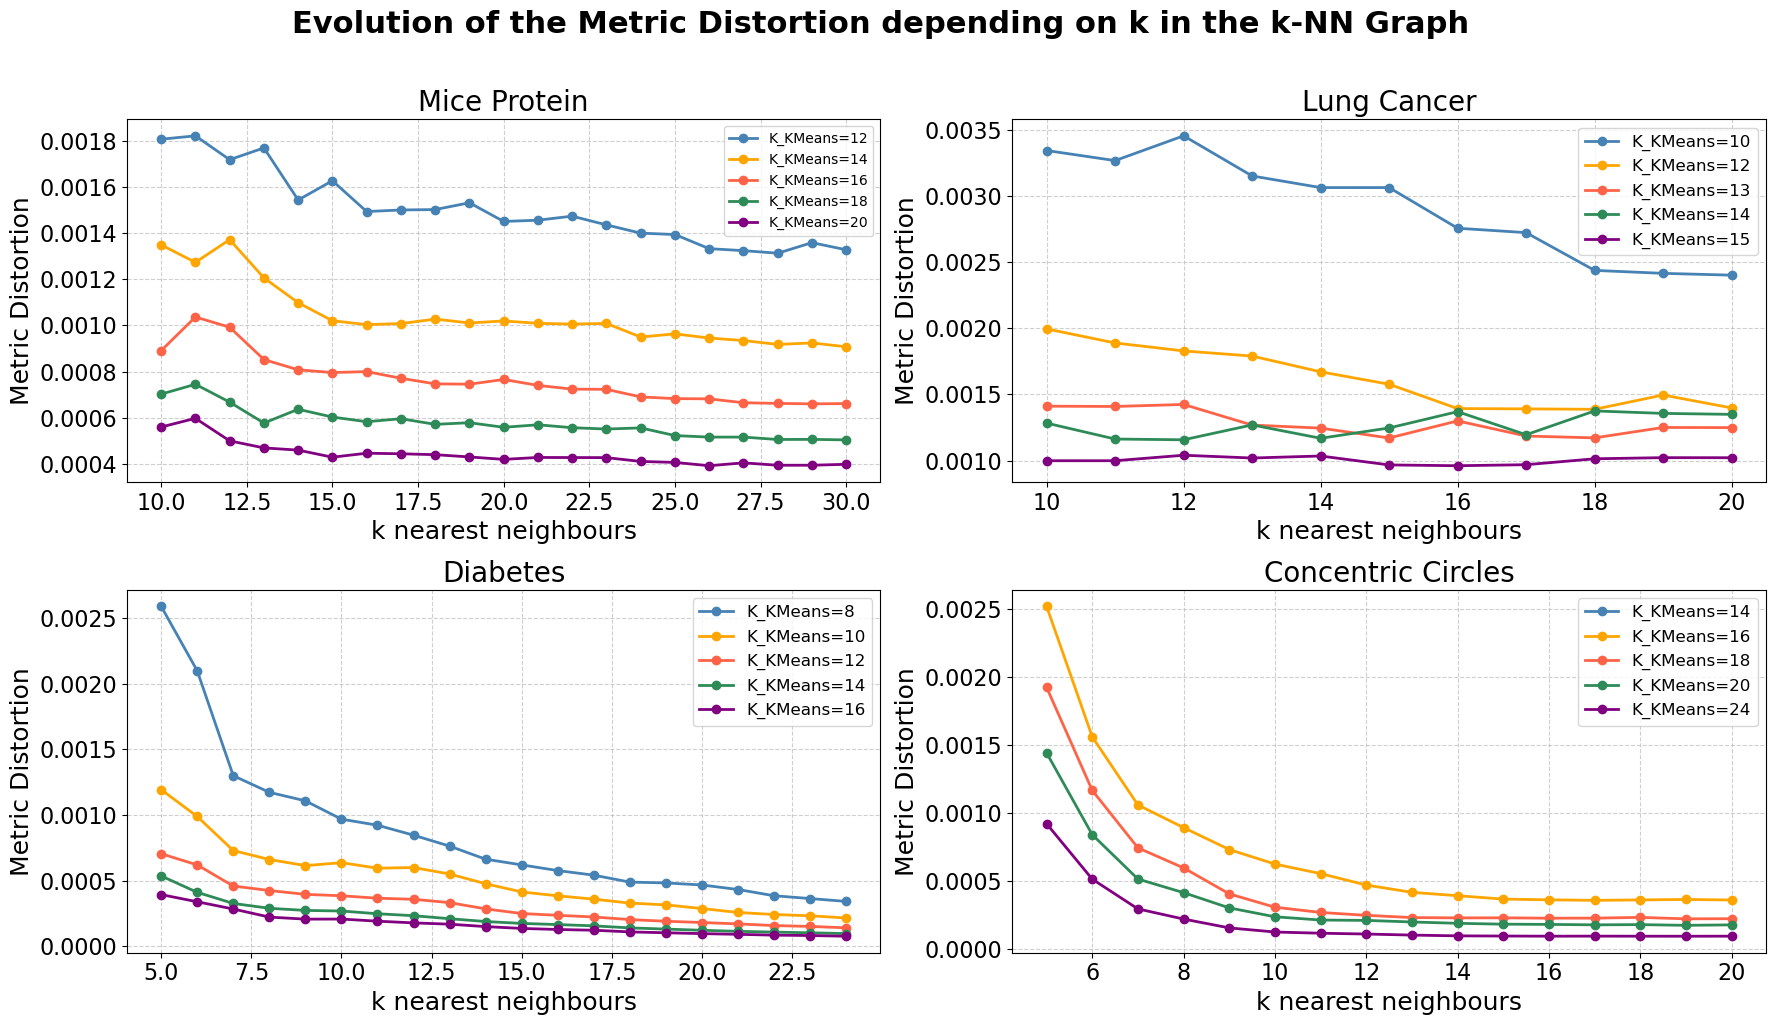

In [2]:
k_kmeans_lines_diabete     = [8, 10, 12, 14, 16]
k_kmeans_lines_circles     = [14, 16, 18, 20, 24]
k_kmeans_lines_mice        = [12, 14, 16, 18, 20]
k_kmeans_lines_lung_cancer = [10, 12, 13, 14, 15]

colors_fig1 = ["steelblue", "orange", "tomato", "seagreen", "purple"]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig1, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 10))

# Mice Protein  (row 1, col 1)
for k_km, color in zip(k_kmeans_lines_mice, colors_fig1):
    filtered = sorted(
        [entry for entry in results_mice if entry["k_kmeans"] == k_km],
        key=lambda x: x["k_knn"]
    )
    knn_vals = [entry["k_knn"]  for entry in filtered]
    md_mins  = [entry["md_min"] for entry in filtered]
    ax1.plot(knn_vals, md_mins, marker="o", color=color, linewidth=2, label=f"K_KMeans={k_km}")
ax1.set_title("Mice Protein", fontsize=20)
ax1.set_xlabel("k nearest neighbours", fontsize=18)
ax1.set_ylabel("Metric Distortion", fontsize=18)
ax1.tick_params(labelsize=16)
ax1.legend(fontsize=10)
ax1.grid(True, linestyle="--", alpha=0.6)

# Lung Cancer  (row 1, col 2)
for k_km, color in zip(k_kmeans_lines_lung_cancer, colors_fig1):
    filtered = sorted(
        [entry for entry in results_lung_cancer if entry["k_kmeans"] == k_km],
        key=lambda x: x["k_knn"]
    )
    knn_vals = [entry["k_knn"]  for entry in filtered]
    md_mins  = [entry["md_min"] for entry in filtered]
    ax2.plot(knn_vals, md_mins, marker="o", color=color, linewidth=2, label=f"K_KMeans={k_km}")
ax2.set_title("Lung Cancer", fontsize=20)
ax2.set_xlabel("k nearest neighbours", fontsize=18)
ax2.set_ylabel("Metric Distortion", fontsize=18)
ax2.tick_params(labelsize=16)
ax2.legend(fontsize=12)
ax2.grid(True, linestyle="--", alpha=0.6)

# Diabetes  (row 2, col 1)
for k_km, color in zip(k_kmeans_lines_diabete, colors_fig1):
    filtered = sorted(
        [entry for entry in results_diabete if entry["k_kmeans"] == k_km],
        key=lambda x: x["k_knn"]
    )
    knn_vals = [entry["k_knn"]  for entry in filtered]
    md_mins  = [entry["md_min"] for entry in filtered]
    ax3.plot(knn_vals, md_mins, marker="o", color=color, linewidth=2, label=f"K_KMeans={k_km}")
ax3.set_title("Diabetes", fontsize=20)
ax3.set_xlabel("k nearest neighbours", fontsize=18)
ax3.set_ylabel("Metric Distortion", fontsize=18)
ax3.tick_params(labelsize=16)
ax3.legend(fontsize=12)
ax3.grid(True, linestyle="--", alpha=0.6)

# Concentric Circles  (row 2, col 2)
for k_km, color in zip(k_kmeans_lines_circles, colors_fig1):
    filtered = sorted(
        [entry for entry in results_circles if entry["k_kmeans"] == k_km],
        key=lambda x: x["k_knn"]
    )
    knn_vals = [entry["k_knn"]  for entry in filtered]
    md_mins  = [entry["md_min"] for entry in filtered]
    ax4.plot(knn_vals, md_mins, marker="o", color=color, linewidth=2, label=f"K_KMeans={k_km}")
ax4.set_title("Concentric Circles", fontsize=20)
ax4.set_xlabel("k nearest neighbours", fontsize=18)
ax4.set_ylabel("Metric Distortion", fontsize=18)
ax4.tick_params(labelsize=16)
ax4.legend(fontsize=12)
ax4.grid(True, linestyle="--", alpha=0.6)

fig1.suptitle("Evolution of the Metric Distortion depending on k in the k-NN Graph", fontsize=22, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("metric_distortion_min_knn_varying.pdf", dpi=250, bbox_inches="tight")
plt.show()

# K Kmeans varying

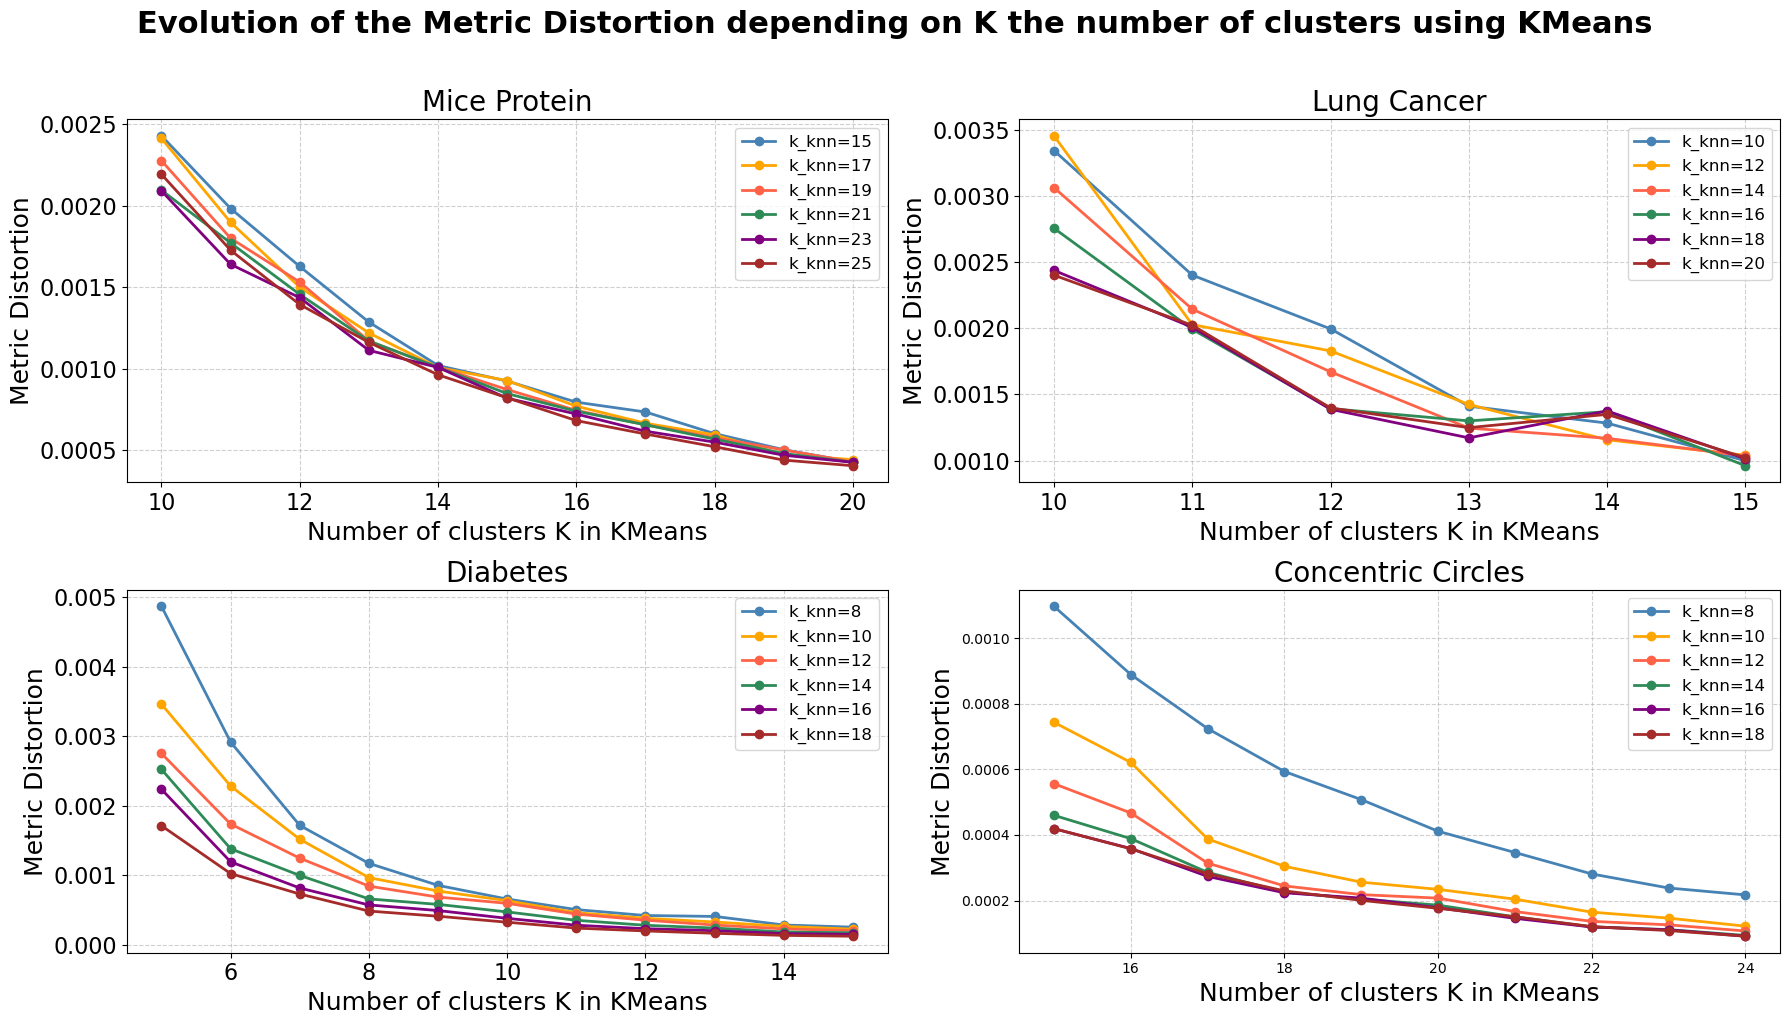

In [3]:
k_knn_lines_diabete     = [8, 10, 12, 14, 16, 18]
k_knn_lines_circles     = [8, 10, 12, 14, 16, 18]
k_knn_lines_mice        = [15, 17, 19, 21, 23, 25]
k_knn_lines_lung_cancer = [10, 12, 14, 16, 18, 20]
colors_fig2 = ["steelblue", "orange", "tomato", "seagreen", "purple", "brown"]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig2, ((ax4, ax5), (ax6, ax7)) = plt.subplots(2, 2, figsize=(18, 10))

# Mice Protein  (row 1, col 1)
for k_kn, color in zip(k_knn_lines_mice, colors_fig2):
    filtered = sorted(
        [entry for entry in results_mice
         if entry["k_knn"] == k_kn and 10 <= entry["k_kmeans"] <= 20],
        key=lambda x: x["k_kmeans"]
    )
    km_vals = [entry["k_kmeans"] for entry in filtered]
    md_mins = [entry["md_min"]   for entry in filtered]
    ax4.plot(km_vals, md_mins, marker="o", color=color, linewidth=2, label=f"k_knn={k_kn}")
ax4.set_title("Mice Protein", fontsize=20)
ax4.set_xlabel("Number of clusters K in KMeans", fontsize=18)
ax4.set_ylabel("Metric Distortion", fontsize=18)
ax4.tick_params(labelsize=16)
ax4.legend(fontsize=12)
ax4.grid(True, linestyle="--", alpha=0.6)

# Lung Cancer  (row 1, col 2)
for k_kn, color in zip(k_knn_lines_lung_cancer, colors_fig2):
    filtered = sorted(
        [entry for entry in results_lung_cancer
         if entry["k_knn"] == k_kn and 8 <= entry["k_kmeans"] <= 16],
        key=lambda x: x["k_kmeans"]
    )
    km_vals = [entry["k_kmeans"] for entry in filtered]
    md_mins = [entry["md_min"]   for entry in filtered]
    ax5.plot(km_vals, md_mins, marker="o", color=color, linewidth=2, label=f"k_knn={k_kn}")
ax5.set_title("Lung Cancer", fontsize=20)
ax5.set_xlabel("Number of clusters K in KMeans", fontsize=18)
ax5.set_ylabel("Metric Distortion", fontsize=18)
ax5.tick_params(labelsize=16)
ax5.legend(fontsize=12)
ax5.grid(True, linestyle="--", alpha=0.6)

# Diabetes  (row 2, col 1)
for k_kn, color in zip(k_knn_lines_diabete, colors_fig2):
    filtered = sorted(
        [entry for entry in results_diabete
         if entry["k_knn"] == k_kn and 5 <= entry["k_kmeans"] <= 15],
        key=lambda x: x["k_kmeans"]
    )
    km_vals = [entry["k_kmeans"] for entry in filtered]
    md_mins = [entry["md_min"]   for entry in filtered]
    ax6.plot(km_vals, md_mins, marker="o", color=color, linewidth=2, label=f"k_knn={k_kn}")
ax6.set_title("Diabetes", fontsize=20)
ax6.set_xlabel("Number of clusters K in KMeans", fontsize=18)
ax6.set_ylabel("Metric Distortion", fontsize=18)
ax6.tick_params(labelsize=16)
ax6.legend(fontsize=12)
ax6.grid(True, linestyle="--", alpha=0.6)

# Concentric Circles  (row 2, col 2)
for k_kn, color in zip(k_knn_lines_circles, colors_fig2):
    filtered = sorted(
        [entry for entry in results_circles
         if entry["k_knn"] == k_kn and 15 <= entry["k_kmeans"] <= 24],
        key=lambda x: x["k_kmeans"]
    )
    km_vals = [entry["k_kmeans"] for entry in filtered]
    md_mins = [entry["md_min"]   for entry in filtered]
    ax7.plot(km_vals, md_mins, marker="o", color=color, linewidth=2, label=f"k_knn={k_kn}")
ax7.set_title("Concentric Circles", fontsize=20)
ax7.set_xlabel("Number of clusters K in KMeans", fontsize=18)
ax7.set_ylabel("Metric Distortion", fontsize=18)
ax7.legend(fontsize=12)
ax7.grid(True, linestyle="--", alpha=0.6)

fig2.suptitle("Evolution of the Metric Distortion depending on K the number of clusters using KMeans", fontsize=22, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("metric_distortion_min_kmeans_varying.pdf", dpi=250, bbox_inches="tight")
plt.show()

# Noisy clustering 

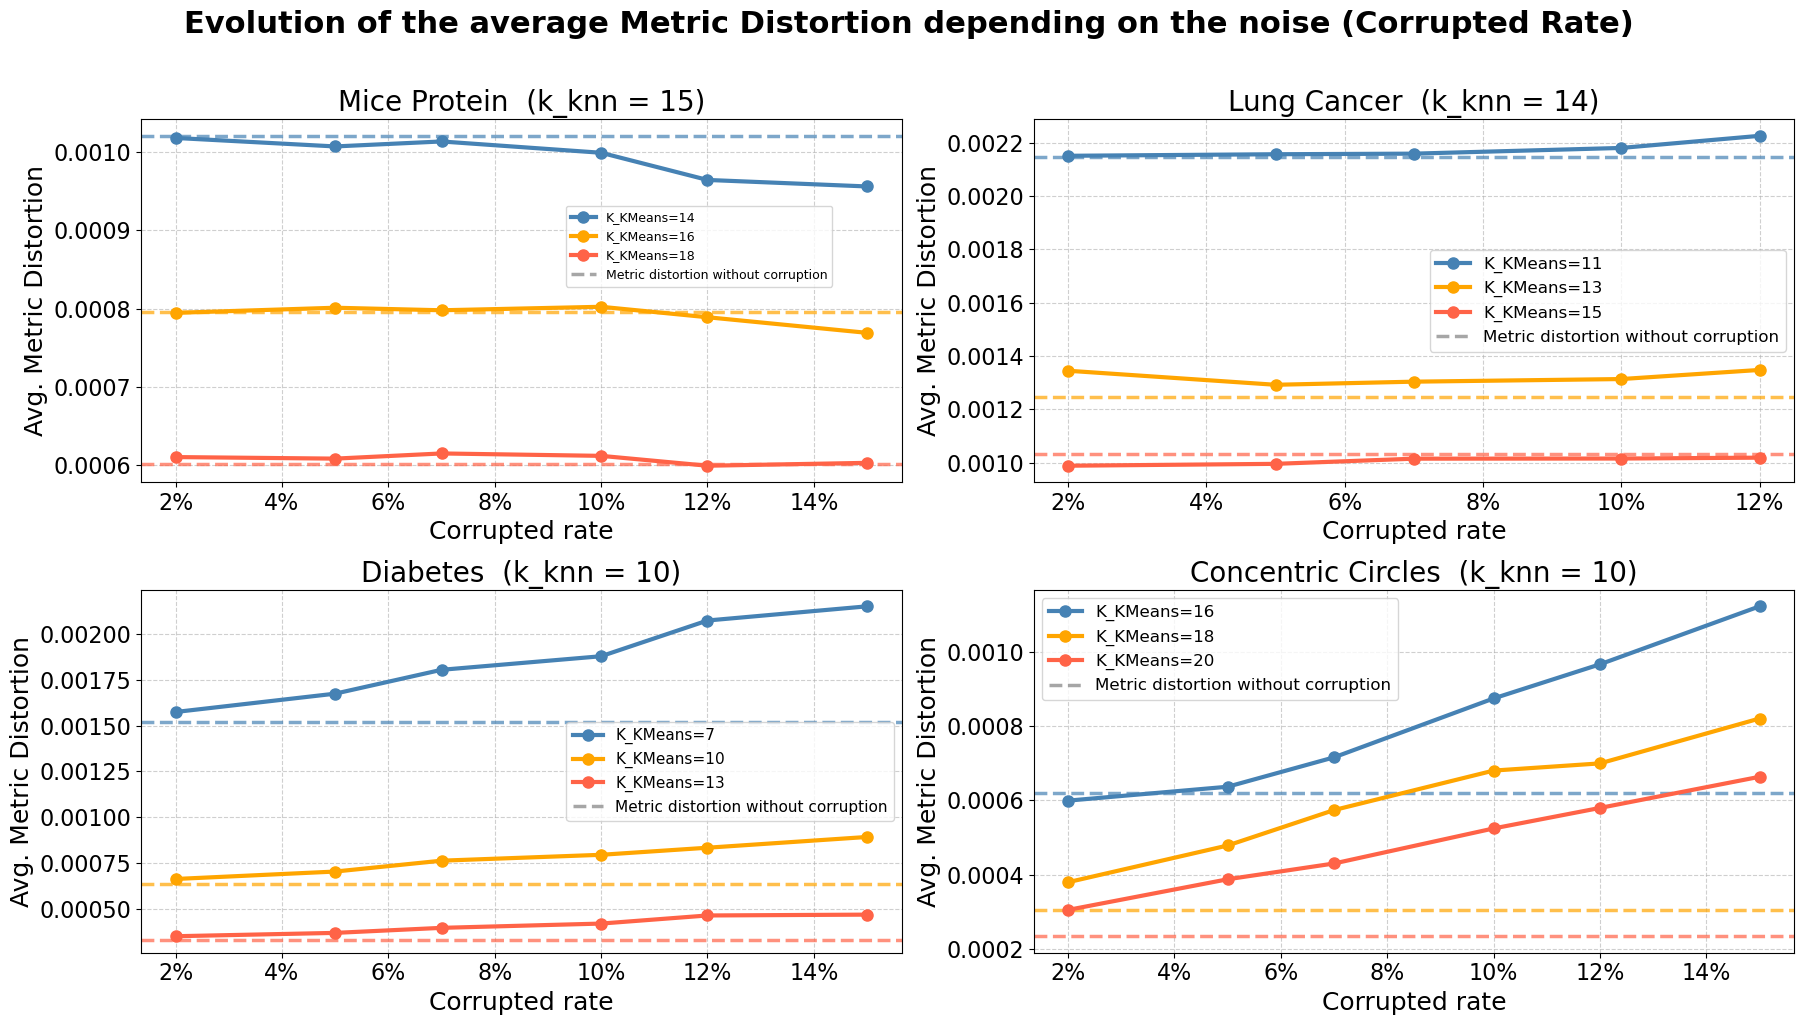

In [4]:
with open("ClusterGraph_results_stability/noise_clustering_robustness_analysis_diabete.json", "r") as f:
    noise_diabete = json.load(f)

with open("ClusterGraph_results_stability/noise_clustering_robustness_analysis_concentric_circles.json", "r") as f:
    noise_circles = json.load(f)

with open("ClusterGraph_results_stability/noise_clustering_robustness_analysis_mice_protein.json", "r") as f:
    noise_mice = json.load(f)

with open("results_robustness/noise_clustering_robustness_analysis_lung_cancer.json", "r") as f:
    noise_lung_cancer = json.load(f)

# ── Config: (title, noise_data, sensitivity_data, k_knn, k_kmeans_vals) ──────
datasets = [
    ("Mice Protein",       noise_mice,        results_mice,        15, [14, 16, 18]),
    ("Lung Cancer",        noise_lung_cancer, results_lung_cancer, 14, [11, 13, 15]),
    ("Diabetes",           noise_diabete,     results_diabete,     10, [7, 10, 13]),
    ("Concentric Circles", noise_circles,     results_circles,     10, [16, 18, 20]),
]
colors_fig3 = ["steelblue", "orange", "tomato"]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig3, axes = plt.subplots(2, 2, figsize=(18, 10))

for i, (ax, (title, noise_data, ref_data, k_knn, k_kmeans_vals)) in enumerate(zip(axes.flat, datasets)):
    for k_km, color in zip(k_kmeans_vals, colors_fig3):
        # Noisy curve
        filtered = sorted(
            [entry for entry in noise_data if entry["k_kmeans"] == k_km],
            key=lambda x: x["corrupted_rate"]
        )
        rates   = [entry["corrupted_rate"] for entry in filtered]
        md_mins = [entry["md_min_avg"]     for entry in filtered]
        ax.plot(rates, md_mins, marker="o", color=color, linewidth=3, markersize=8, label=f"K_KMeans={k_km}")

        # Dashed horizontal reference line (no noise) — looked up live from sensitivity data
        ref_entries = [e for e in ref_data if e["k_knn"] == k_knn and e["k_kmeans"] == k_km]
        if ref_entries:
            ref_val = ref_entries[0]["md_min"]
            ax.axhline(y=ref_val, color=color, linestyle="--", linewidth=2.5, alpha=0.7)
        else:
            print(f"[WARNING] No reference entry found for {title}, k_knn={k_knn}, k_kmeans={k_km}")

    # Add a custom legend entry explaining the dashed lines
    reference_entry = Line2D([0], [0], color="gray", linestyle="--", linewidth=2.5,
                             alpha=0.7, label="Metric distortion without corruption")
    handles, labels = ax.get_legend_handles_labels()

    if i == 0:
        ax.legend(handles=handles + [reference_entry], labels=labels + ["Metric distortion without corruption"],
                  fontsize=9, loc="center left", bbox_to_anchor=(0.55, 0.65))
    else:
        if i==2:
            font_size_legend=11
        else:
            font_size_legend=12
        ax.legend(handles=handles + [reference_entry], labels=labels + ["Metric distortion without corruption"],
                  fontsize=font_size_legend, loc="best")

    ax.set_title(f"{title}  (k_knn = {k_knn})", fontsize=20)
    ax.set_xlabel("Corrupted rate", fontsize=18)
    ax.set_ylabel("Avg. Metric Distortion", fontsize=18)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.tick_params(labelsize=16)
    ax.grid(True, linestyle="--", alpha=0.6)

fig3.suptitle(
    "Evolution of the average Metric Distortion depending on the noise (Corrupted Rate)",
    fontsize=22, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("metric_distortion_min_noise_robustness.pdf", dpi=250, bbox_inches="tight")
plt.show()